# All-Fold Model Evaluation

Evaluate the cross-validation models across **every available fold** instead of only `fold_1`.

This notebook mirrors the structure of `model_evaluation.ipynb`, but:

- loads data for any fold dynamically,
- discovers fold weights automatically,
- aggregates results across folds,
- optionally evaluates IQM hardware for all selected folds.

**Recommended kernel:** `Python (QC1 uv)` or `Python (QC1 clean)`.

Skip any package-install workflow inside the notebook if your environment is already set up.

In [ ]:
import sys
import time
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit.primitives import PrimitiveResult, PubResult, StatevectorEstimator
from qiskit.primitives.base import BaseEstimatorV2
from qiskit.primitives.containers.data_bin import DataBin
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms.gradients import ReverseEstimatorGradient
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import EstimatorQNN
from sklearn.metrics import accuracy_score, f1_score

try:
    from tqdm import tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False
    print("tqdm not available; falling back to plain progress output.")

## Circuit Definitions

Hardware-efficient ansatz and the hybrid model building blocks reused from the original evaluation notebook.

In [ ]:
def ansatz(n_qubits, depth):
    """
    Ansatz with Ring topology.
    Uses exclusively native-like gates: Rx, Ry, Rz, and Cz.
    """
    params_per_iter = 4 * n_qubits
    theta = ParameterVector('θ', params_per_iter * (depth // 2))

    qc = QuantumCircuit(n_qubits)

    for j in range(depth // 2):
        offset = j * params_per_iter

        for i in range(n_qubits):
            qc.ry(theta[offset + i], i)

        for i in range(n_qubits):
            control = i
            target = (i + 1) % n_qubits
            param_idx = offset + n_qubits + i
            qc.rz(theta[param_idx], target)
            qc.cz(control, target)

        offset_l2 = offset + 2 * n_qubits

        for i in range(n_qubits):
            qc.rx(theta[offset_l2 + i], i)

        for i in range(n_qubits):
            control = i
            target = (i - 1) % n_qubits
            param_idx = offset_l2 + n_qubits + i
            qc.ry(theta[param_idx], target)
            qc.cz(control, target)

    return qc

## IQM Backend Estimator

Custom estimator for IQM hardware execution with per-job timing capture.

In [ ]:
class SimpleIQMJob:
    """A dummy job that simply holds the result."""

    def __init__(self, result):
        self._result = result

    def result(self):
        return self._result


class IQMBackendEstimator(BaseEstimatorV2):
    def __init__(self, backend, options=None):
        super().__init__()
        self._backend = backend
        self._options = options or {"shots": 100}
        self.timestamp_history = []
        self.total_qpu_time = 0.0

    def _extract_timestamps(self, result):
        try:
            timeline = result._metadata.get('timeline', [])
            if not timeline:
                return None

            timestamps = {}
            for entry in timeline:
                timestamps[entry.status] = entry.timestamp
            return timestamps
        except Exception:
            return None

    def _counts_to_expectation(self, counts):
        if isinstance(counts, list):
            counts = counts[0]
        shots = sum(counts.values())
        count_0 = sum(c for bs, c in counts.items() if bs[-1] == '0')
        p0 = count_0 / shots if shots else 0
        return p0 - (1 - p0)

    def run(self, pubs, precision=None):
        if not isinstance(pubs, list):
            pubs = [pubs]

        job_results = []
        shots_opt = self._options["shots"]
        max_circuits = self._options.get("max_circuits_per_job")

        base_circuit = pubs[0][0]
        circuit_with_meas = base_circuit.copy()
        if circuit_with_meas.num_clbits == 0:
            circuit_with_meas.measure_all()
        transpiled_qc = transpile(circuit_with_meas, self._backend, optimization_level=3)

        for pub in pubs:
            _, observables, parameter_values = pub
            if parameter_values.ndim == 1:
                parameter_values = [parameter_values]

            bound_circuits = [transpiled_qc.assign_parameters(params) for params in parameter_values]
            n_circuits = len(bound_circuits)
            pub_expectations = []

            for start in range(0, n_circuits, max_circuits or n_circuits):
                end = min(start + (max_circuits or n_circuits), n_circuits)
                batch = bound_circuits[start:end]
                try:
                    job = self._backend.run(batch, shots=shots_opt)
                    result = job.result()

                    ts = self._extract_timestamps(result)
                    if ts:
                        exec_start = ts.get('execution_started')
                        exec_end = ts.get('execution_ended')
                        comp_start = ts.get('compilation_started')
                        comp_end = ts.get('compilation_ended')
                        job_created = ts.get('created')
                        job_completed = ts.get('completed')
                        if exec_start and exec_end:
                            execution_time = (exec_end - exec_start).total_seconds()
                            compile_time = (comp_end - comp_start).total_seconds() if comp_start and comp_end else 0
                            job_time = (job_completed - job_created).total_seconds() if job_created and job_completed else 0
                            self.timestamp_history.append({
                                'execution_time_qpu': execution_time,
                                'job_time_total': job_time,
                                'compile_time': compile_time,
                                'raw_timestamps': ts,
                                'n_circuits': len(batch),
                            })
                            self.total_qpu_time += execution_time
                            print(
                                f"Batch of {len(batch)} circuits | QPU: {execution_time * 1000:.0f}ms | "
                                f"Compile: {compile_time * 1000:.0f}ms | Job: {job_time:.3f}s"
                            )

                    counts_list = result.get_counts()
                    if not isinstance(counts_list, list):
                        counts_list = [counts_list]
                    for counts in counts_list:
                        pub_expectations.append(self._counts_to_expectation(counts))
                except Exception as e:
                    print(f"Batch job failed: {e}")
                    pub_expectations.extend([0.0] * len(batch))

            data = DataBin(evs=np.array(pub_expectations), shape=(len(pub_expectations),))
            job_results.append(PubResult(data=data))

        return SimpleIQMJob(PrimitiveResult(job_results))

## Hybrid Quantum-Classical Model

PyTorch wrapper around the variational quantum circuit.

In [ ]:
RANDOM_SEED = 42


class HybridModel(nn.Module):
    def __init__(self, ansatz_circuit, num_qubits):
        super().__init__()
        self.feature_map = self.angle_encoding(num_qubits)

        self.qc = QuantumCircuit(num_qubits)
        self.qc.compose(self.feature_map, qubits=range(num_qubits), inplace=True)
        self.qc.compose(ansatz_circuit, inplace=True)

        input_params = list(self.feature_map.parameters)
        weight_params = list(ansatz_circuit.parameters)
        observable = SparsePauliOp.from_list([("I" * (num_qubits - 1) + "Z", 1)])
        estimator = StatevectorEstimator(seed=RANDOM_SEED)
        gradient = ReverseEstimatorGradient(estimator)

        self.qnn = EstimatorQNN(
            circuit=self.qc,
            observables=observable,
            input_params=input_params,
            weight_params=weight_params,
            estimator=estimator,
            gradient=gradient,
        )
        self.quantum_layer = TorchConnector(self.qnn)

    def angle_encoding(self, num_qubits):
        qc_data = QuantumCircuit(num_qubits)
        input_params = ParameterVector('x', num_qubits)
        for i in range(num_qubits):
            qc_data.ry(input_params[i], i)
        return qc_data

    def forward(self, x):
        return self.quantum_layer(x)

## Helper Functions

Fold-aware helpers for locating data, locating weights, loading models, and building statevector/IQM variants.

In [ ]:
NUM_QUBITS = 5
ANSATZ_DEPTH = 2
DEFAULT_MODEL_SOURCES = ["ideal", "noise"]
DEFAULT_CHECKPOINT = "final"

SOURCE_LABELS = {
    "ideal": "Noiseless-trained",
    "noise": "Noisy-trained",
}

SOURCE_COLORS = {
    "ideal": "tab:blue",
    "noise": "tab:orange",
}


def _project_root():
    """Project root: directory containing cross_validation/."""
    for cwd in [Path.cwd(), Path.cwd().parent]:
        if (cwd / "cross_validation").exists():
            return cwd
    return Path.cwd()


def available_folds():
    root = _project_root() / "cross_validation"
    folds = []
    for path in sorted(root.glob("fold_*")):
        if path.is_dir():
            try:
                folds.append(int(path.name.split("_")[1]))
            except (IndexError, ValueError):
                pass
    return folds


def _fold_dir(fold_idx):
    path = _project_root() / "cross_validation" / f"fold_{fold_idx}"
    if not path.exists():
        raise FileNotFoundError(f"Fold directory does not exist: {path}")
    return path


def load_fold_data(fold_idx, force_reload=True):
    cache = globals().setdefault("_fold_data_cache", {})
    if not force_reload and fold_idx in cache:
        X_test, y_test = cache[fold_idx]
        print(f"✓ Using cached fold {fold_idx} test data: {X_test.shape[0]} samples")
        return X_test, y_test

    path = _fold_dir(fold_idx) / "test_data.csv"
    fold_data = np.loadtxt(path, delimiter=",", skiprows=1, ndmin=2)
    if fold_data.shape[1] != 6:
        raise ValueError(f"Expected 6 columns in {path}, got {fold_data.shape[1]}")

    X_test = fold_data[:, :5].astype(np.float32)
    y_test = fold_data[:, 5].astype(np.float32)
    cache[fold_idx] = (X_test, y_test)
    print(f"✓ Loaded fold {fold_idx} test data: {X_test.shape[0]} samples")
    return X_test, y_test


def _candidate_weight_paths(fold_idx, source="noise", checkpoint="final"):
    if source not in {"ideal", "noise"}:
        raise ValueError(f"Unsupported source: {source}")
    if checkpoint not in {"final", "best"}:
        raise ValueError(f"Unsupported checkpoint: {checkpoint}")

    fold_dir = _fold_dir(fold_idx)
    suffix = "noise_" if source == "noise" else ""
    explicit = fold_dir / f"fold_{fold_idx}_depth_{ANSATZ_DEPTH}_{suffix}{checkpoint}_weights.pth"
    legacy = fold_dir / f"model_depth_{ANSATZ_DEPTH}_{suffix}{checkpoint}_weights.pth"
    globbed = sorted(fold_dir.glob(f"*depth_{ANSATZ_DEPTH}*{suffix}{checkpoint}_weights.pth"))

    candidates = []
    for path in [explicit, legacy, *globbed]:
        if path not in candidates:
            candidates.append(path)
    return candidates


def load_fold_weights(model, fold_idx, strip_prefix=False, source="noise", checkpoint="final"):
    candidate_paths = [path for path in _candidate_weight_paths(fold_idx, source=source, checkpoint=checkpoint) if path.exists()]
    if not candidate_paths:
        searched = [str(path) for path in _candidate_weight_paths(fold_idx, source=source, checkpoint=checkpoint)]
        raise FileNotFoundError(
            f"No weights found for fold={fold_idx}, source={source}, checkpoint={checkpoint}. Searched: {searched}"
        )

    path = candidate_paths[0]
    loaded_state = torch.load(path, map_location="cpu")
    if strip_prefix:
        adjusted_state = {}
        for key, value in loaded_state.items():
            if key.startswith("quantum_layer."):
                adjusted_state[key.replace("quantum_layer.", "", 1)] = value
            else:
                adjusted_state[key] = value
        loaded_state = adjusted_state

    model.load_state_dict(loaded_state)
    print(f"✓ Loaded fold {fold_idx} {source} {checkpoint} weights from {path.name}")
    return path


def connect_to_iqm_backend():
    global iqm_backend

    if 'iqm_backend' not in globals() or iqm_backend is None:
        print("\n⚠️ IQM backend not found. Connecting...")
        try:
            base_url = "https://odra5.e-science.pl/"
            token = input("Enter IQM Token: ")
            from iqm.qiskit_iqm import IQMProvider

            provider = IQMProvider(base_url, token=token)
            iqm_backend = provider.get_backend()
            print(f"✓ Connected to backend: {iqm_backend.name}")
        except Exception as e:
            print(f"✗ Connection error: {e}")
            raise RuntimeError("Failed to connect to IQM backend") from e

    return iqm_backend


def build_statevector_model(num_qubits=5, depth=2):
    return HybridModel(ansatz(num_qubits, depth), num_qubits)


def build_iqm_model(iqm_backend, n_shots, num_qubits=5, depth=2):
    hw_estimator = IQMBackendEstimator(iqm_backend, options={"shots": n_shots})
    hw_ansatz = ansatz(num_qubits, depth)
    hw_feature_map = HybridModel(hw_ansatz, num_qubits).angle_encoding(num_qubits)

    hw_qc = QuantumCircuit(num_qubits)
    hw_qc.compose(hw_feature_map, qubits=range(num_qubits), inplace=True)
    hw_qc.compose(hw_ansatz, inplace=True)

    observable = SparsePauliOp.from_list([("I" * (num_qubits - 1) + "Z", 1)])
    hw_qnn = EstimatorQNN(
        circuit=hw_qc,
        observables=observable,
        input_params=list(hw_feature_map.parameters),
        weight_params=list(hw_ansatz.parameters),
        estimator=hw_estimator,
    )
    hw_model = TorchConnector(hw_qnn)
    return hw_model, hw_estimator


def predictions_to_labels(predictions):
    predictions = np.asarray(predictions).reshape(-1)
    return np.where(predictions > 0, 1, -1).astype(np.float32)


print(f"✓ Available folds: {available_folds()}")

✓ Available folds: [1, 2, 3, 4, 5]


## All-Fold Evaluation

This cell evaluates every selected fold for both `ideal` and `noise` sources.

For each fold/source combination it computes:

1. `StatevectorEstimator` accuracy and latency
2. optional IQM hardware accuracy and QPU time for each requested shot count
3. aggregate summaries across all evaluated folds

Leave the shot-count input blank if you want a fast simulator-only sweep first.

In [ ]:
print("\n" + "=" * 72)
print("ALL-FOLD MODEL EVALUATION - STATEVECTOR vs IQM")
print("=" * 72)

available = available_folds()
if not available:
    raise RuntimeError("No fold directories were found under cross_validation/.")

fold_input = input(
    f"Enter folds to evaluate (comma-separated) [default: {','.join(map(str, available))}]: "
).strip()
if fold_input:
    selected_folds = sorted({int(part.strip()) for part in fold_input.split(',') if part.strip()})
else:
    selected_folds = available
invalid_folds = [fold for fold in selected_folds if fold not in available]
if invalid_folds:
    raise ValueError(f"Unknown folds requested: {invalid_folds}")

source_input = input("Enter model sources to evaluate (ideal,noise) [default: ideal,noise]: ").strip()
if source_input:
    model_sources = [part.strip() for part in source_input.split(',') if part.strip()]
else:
    model_sources = DEFAULT_MODEL_SOURCES.copy()
invalid_sources = [source for source in model_sources if source not in DEFAULT_MODEL_SOURCES]
if invalid_sources:
    raise ValueError(f"Unsupported model sources: {invalid_sources}")

checkpoint_input = input(f"Checkpoint type (final/best) [default: {DEFAULT_CHECKPOINT}]: ").strip() or DEFAULT_CHECKPOINT
if checkpoint_input not in {"final", "best"}:
    raise ValueError(f"Unsupported checkpoint: {checkpoint_input}")

shot_input = input("Enter shot counts (comma-separated) or leave blank to skip IQM: ").strip()
if shot_input:
    shot_counts = sorted({int(part.strip()) for part in shot_input.split(',') if part.strip()})
    if any(shot <= 0 for shot in shot_counts):
        raise ValueError("All shot counts must be positive integers")
else:
    shot_counts = []

print(f"✓ Folds: {selected_folds}")
print(f"✓ Sources: {model_sources}")
print(f"✓ Checkpoint: {checkpoint_input}")
print(f"✓ IQM shots: {shot_counts if shot_counts else 'skipped'}")

all_rows = []
timing_estimators = {}
iqm_backend = None

if shot_counts:
    iqm_backend = connect_to_iqm_backend()
    print()

for fold_idx in selected_folds:
    print("\n" + "-" * 72)
    print(f"Evaluating fold {fold_idx}")
    print("-" * 72)

    X_test, y_test = load_fold_data(fold_idx, force_reload=True)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    n_samples = len(X_test)

    for source in model_sources:
        label = SOURCE_LABELS.get(source, source)

        try:
            model_sv = build_statevector_model(NUM_QUBITS, ANSATZ_DEPTH)
            weight_path = load_fold_weights(
                model_sv,
                fold_idx,
                strip_prefix=False,
                source=source,
                checkpoint=checkpoint_input,
            )
            model_sv.eval()

            start_time = time.time()
            with torch.no_grad():
                sv_predictions = model_sv(X_test_tensor).detach().cpu().numpy().flatten()
            sv_time_total = time.time() - start_time
            sv_time = sv_time_total / n_samples
            sv_labels = predictions_to_labels(sv_predictions)
            sv_accuracy = accuracy_score(y_test, sv_labels)
            sv_f1 = f1_score(y_test, sv_labels, pos_label=1)

            all_rows.append({
                "fold": fold_idx,
                "source": source,
                "model_label": label,
                "backend": "StatevectorEstimator",
                "shots": np.nan,
                "accuracy": sv_accuracy,
                "f1": sv_f1,
                "time_per_sample": sv_time,
                "weight_path": str(weight_path),
                "status": "ok",
            })
            print(
                f"Fold {fold_idx} | {label:<18} | Statevector "
                f"acc={sv_accuracy:.4f} | f1={sv_f1:.4f} | time/sample={sv_time:.6f}s"
            )
        except Exception as e:
            all_rows.append({
                "fold": fold_idx,
                "source": source,
                "model_label": label,
                "backend": "StatevectorEstimator",
                "shots": np.nan,
                "accuracy": np.nan,
                "f1": np.nan,
                "time_per_sample": np.nan,
                "weight_path": "",
                "status": f"failed: {e}",
            })
            print(f"✗ Fold {fold_idx} | {label} | Statevector failed: {e}")

        if not shot_counts:
            continue

        iterator = tqdm(shot_counts, desc=f"Fold {fold_idx} {source}", unit="shots") if HAS_TQDM else shot_counts
        for n_shots in iterator:
            try:
                hw_model, hw_estimator = build_iqm_model(
                    iqm_backend,
                    n_shots,
                    num_qubits=NUM_QUBITS,
                    depth=ANSATZ_DEPTH,
                )
                weight_path = load_fold_weights(
                    hw_model,
                    fold_idx,
                    strip_prefix=True,
                    source=source,
                    checkpoint=checkpoint_input,
                )

                with torch.no_grad():
                    hw_predictions = hw_model(X_test_tensor).detach().cpu().numpy().flatten()

                hw_labels = predictions_to_labels(hw_predictions)
                hw_accuracy = accuracy_score(y_test, hw_labels)
                hw_f1 = f1_score(y_test, hw_labels, pos_label=1)
                hw_qpu_time = hw_estimator.total_qpu_time / n_samples

                all_rows.append({
                    "fold": fold_idx,
                    "source": source,
                    "model_label": label,
                    "backend": "IQM",
                    "shots": n_shots,
                    "accuracy": hw_accuracy,
                    "f1": hw_f1,
                    "time_per_sample": hw_qpu_time,
                    "weight_path": str(weight_path),
                    "status": "ok",
                })
                timing_estimators[(fold_idx, source, n_shots)] = hw_estimator

                if HAS_TQDM:
                    iterator.set_postfix({"acc": f"{hw_accuracy:.4f}", "f1": f"{hw_f1:.4f}"})
                else:
                    print(
                        f"Fold {fold_idx} | {label:<18} | IQM shots={n_shots:<6} "
                        f"acc={hw_accuracy:.4f} | f1={hw_f1:.4f}"
                    )
            except Exception as e:
                all_rows.append({
                    "fold": fold_idx,
                    "source": source,
                    "model_label": label,
                    "backend": "IQM",
                    "shots": n_shots,
                    "accuracy": np.nan,
                    "f1": np.nan,
                    "time_per_sample": np.nan,
                    "weight_path": "",
                    "status": f"failed: {e}",
                })
                print(f"✗ Fold {fold_idx} | {label} | IQM shots={n_shots} failed: {e}")

all_folds_df = pd.DataFrame(all_rows)

if all_folds_df.empty:
    raise RuntimeError("No evaluation rows were produced.")

summary_df = all_folds_df.copy()
summary_df["shots"] = summary_df["shots"].apply(lambda x: "Statevector" if pd.isna(x) else int(x))
summary_df["accuracy"] = summary_df["accuracy"].apply(lambda x: "FAILED" if pd.isna(x) else f"{x:.4f}")
summary_df["f1"] = summary_df["f1"].apply(lambda x: "FAILED" if pd.isna(x) else f"{x:.4f}")
summary_df["time_per_sample"] = summary_df["time_per_sample"].apply(lambda x: "N/A" if pd.isna(x) else f"{x:.6f}")

print("\n" + "=" * 72)
print("DETAILED RESULTS")
print("=" * 72)
print(
    summary_df[["fold", "model_label", "backend", "shots", "accuracy", "f1", "time_per_sample", "status"]]
    .sort_values(["fold", "model_label", "backend", "shots"], na_position="first")
    .to_string(index=False)
)

ok_df = all_folds_df[all_folds_df["status"] == "ok"].copy()
aggregate_df = pd.DataFrame()
if not ok_df.empty:
    aggregate_df = (
        ok_df.groupby(["source", "model_label", "backend", "shots"], dropna=False)
        .agg(
            folds_evaluated=("fold", "nunique"),
            mean_accuracy=("accuracy", "mean"),
            std_accuracy=("accuracy", "std"),
            mean_f1=("f1", "mean"),
            std_f1=("f1", "std"),
            mean_time_per_sample=("time_per_sample", "mean"),
            std_time_per_sample=("time_per_sample", "std"),
        )
        .reset_index()
        .fillna({
            "std_accuracy": 0.0,
            "std_f1": 0.0,
            "std_time_per_sample": 0.0,
        })
    )

    aggregate_print = aggregate_df.copy()
    aggregate_print["shots"] = aggregate_print["shots"].apply(lambda x: "Statevector" if pd.isna(x) else int(x))
    for column in ["mean_accuracy", "std_accuracy", "mean_f1", "std_f1", "mean_time_per_sample", "std_time_per_sample"]:
        aggregate_print[column] = aggregate_print[column].map(lambda x: f"{x:.6f}")

    print("\n" + "=" * 72)
    print("AGGREGATE RESULTS ACROSS FOLDS")
    print("=" * 72)
    print(
        aggregate_print[[
            "model_label",
            "backend",
            "shots",
            "folds_evaluated",
            "mean_accuracy",
            "std_accuracy",
            "mean_f1",
            "std_f1",
            "mean_time_per_sample",
        ]].to_string(index=False)
    )
else:
    print("\n⚠️ No successful runs were recorded, so no aggregate summary is available.")

## Aggregate Visualization

Plots the fold-averaged accuracy and latency curves for each model source. Statevector runs are shown as horizontal baselines; IQM runs are shown against shot count.

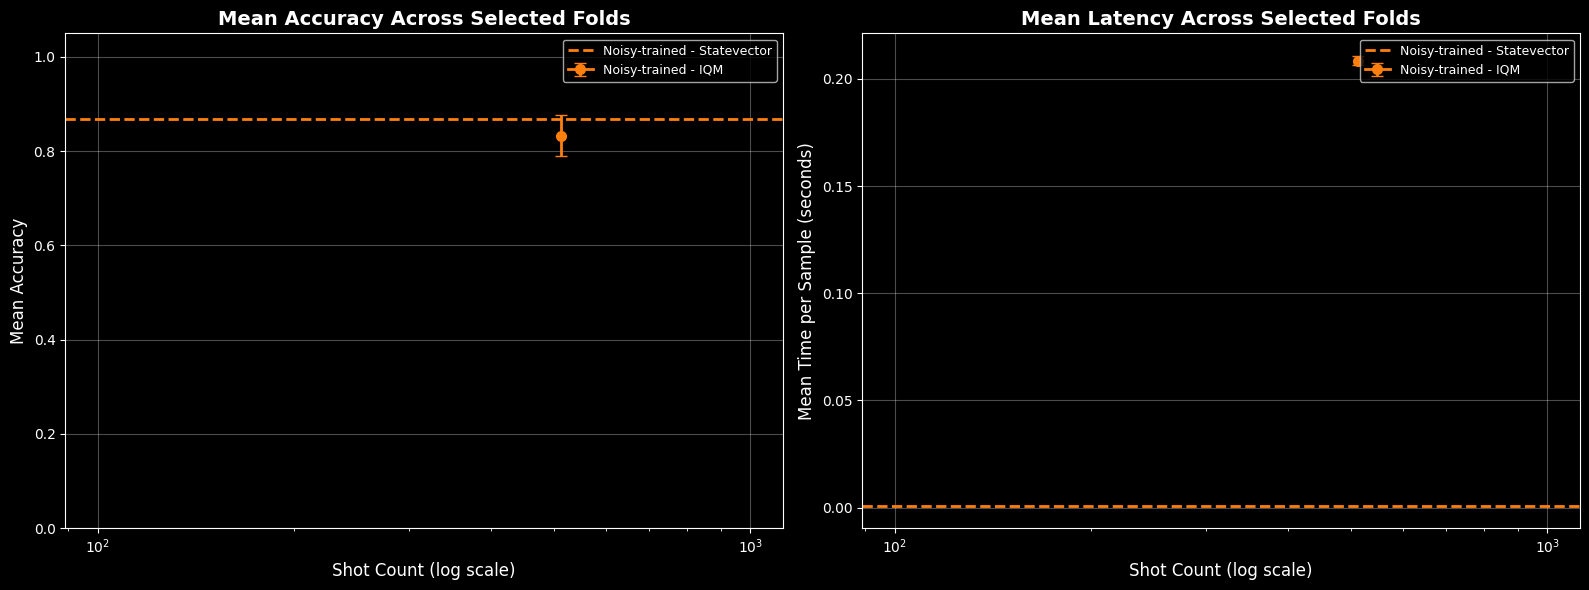

In [ ]:
if 'aggregate_df' not in globals() or aggregate_df.empty:
    print("Run the all-fold evaluation cell first.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    plotted_hardware = False

    for source in DEFAULT_MODEL_SOURCES:
        color = SOURCE_COLORS.get(source)
        label = SOURCE_LABELS.get(source, source)

        sv_rows = aggregate_df[
            (aggregate_df['source'] == source)
            & (aggregate_df['backend'] == 'StatevectorEstimator')
        ]
        hw_rows = aggregate_df[
            (aggregate_df['source'] == source)
            & (aggregate_df['backend'] == 'IQM')
        ].sort_values('shots')

        if not sv_rows.empty:
            sv_row = sv_rows.iloc[0]
            ax1.axhline(
                y=sv_row['mean_accuracy'],
                color=color,
                linestyle='--',
                linewidth=2,
                label=f'{label} - Statevector',
            )
            ax2.axhline(
                y=sv_row['mean_time_per_sample'],
                color=color,
                linestyle='--',
                linewidth=2,
                label=f'{label} - Statevector',
            )

        if not hw_rows.empty:
            plotted_hardware = True
            ax1.errorbar(
                hw_rows['shots'],
                hw_rows['mean_accuracy'],
                yerr=hw_rows['std_accuracy'],
                fmt='o-',
                color=color,
                linewidth=2,
                markersize=7,
                capsize=4,
                label=f'{label} - IQM',
            )
            ax2.errorbar(
                hw_rows['shots'],
                hw_rows['mean_time_per_sample'],
                yerr=hw_rows['std_time_per_sample'],
                fmt='o-',
                color=color,
                linewidth=2,
                markersize=7,
                capsize=4,
                label=f'{label} - IQM',
            )

    if plotted_hardware:
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    ax1.set_xlabel('Shot Count (log scale)', fontsize=12)
    ax1.set_ylabel('Mean Accuracy', fontsize=12)
    ax1.set_title('Mean Accuracy Across Selected Folds', fontsize=14, fontweight='bold')
    ax1.set_ylim([0, 1.05])
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9)

    ax2.set_xlabel('Shot Count (log scale)', fontsize=12)
    ax2.set_ylabel('Mean Time per Sample (seconds)', fontsize=12)
    ax2.set_title('Mean Latency Across Selected Folds', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

## Per-Fold Statevector Snapshot

Useful for seeing fold-to-fold variation on the fast simulator baseline before running hardware jobs.

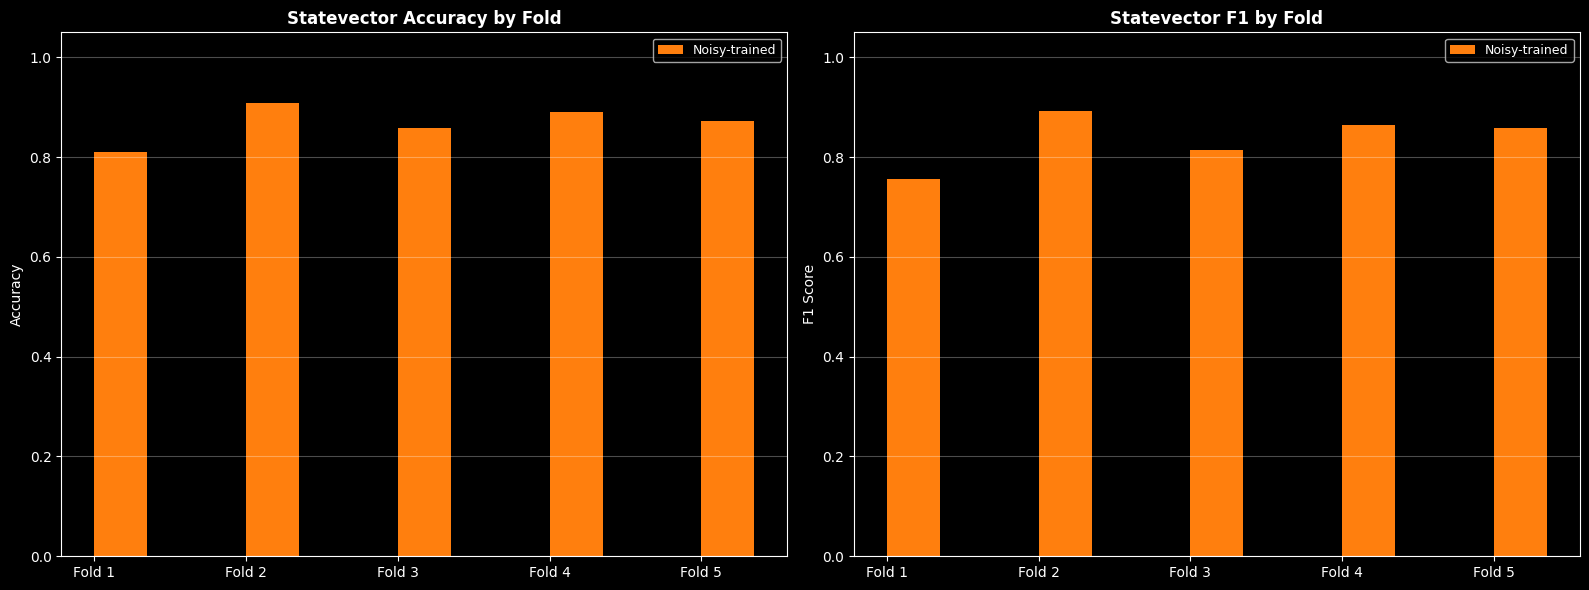

In [ ]:
if 'all_folds_df' not in globals() or all_folds_df.empty:
    print("Run the all-fold evaluation cell first.")
else:
    statevector_df = all_folds_df[
        (all_folds_df['backend'] == 'StatevectorEstimator')
        & (all_folds_df['status'] == 'ok')
    ].copy()

    if statevector_df.empty:
        print("No successful StatevectorEstimator runs are available.")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        x = np.arange(len(sorted(statevector_df['fold'].unique())))
        width = 0.35

        for idx, source in enumerate(DEFAULT_MODEL_SOURCES):
            src_df = statevector_df[statevector_df['source'] == source].sort_values('fold')
            if src_df.empty:
                continue
            axes[0].bar(
                x + (idx - 0.5) * width,
                src_df['accuracy'],
                width=width,
                color=SOURCE_COLORS.get(source),
                label=SOURCE_LABELS.get(source, source),
            )
            axes[1].bar(
                x + (idx - 0.5) * width,
                src_df['f1'],
                width=width,
                color=SOURCE_COLORS.get(source),
                label=SOURCE_LABELS.get(source, source),
            )

        fold_labels = sorted(statevector_df['fold'].unique())
        for ax, metric in zip(axes, ['Accuracy', 'F1 Score']):
            ax.set_xticks(x)
            ax.set_xticklabels([f'Fold {fold}' for fold in fold_labels])
            ax.set_ylim([0, 1.05])
            ax.set_ylabel(metric)
            ax.grid(True, axis='y', alpha=0.3)
            ax.legend(fontsize=9)

        axes[0].set_title('Statevector Accuracy by Fold', fontweight='bold')
        axes[1].set_title('Statevector F1 by Fold', fontweight='bold')
        plt.tight_layout()
        plt.show()

## IQM Job Timing Breakdown

Inspect one evaluated `(fold, model source, shot count)` configuration from `timing_estimators`.

In [ ]:
print("\n" + "=" * 72)
print("IQM JOB TIMING BREAKDOWN")
print("=" * 72)

if 'timing_estimators' not in globals() or not timing_estimators:
    print("No timing data available. Run the all-fold evaluation cell with IQM shots first.")
else:
    available_configs = sorted(timing_estimators.keys())
    print("\nAvailable timing configurations:")
    for fold_idx, source, shots in available_configs:
        print(f"  fold={fold_idx} | source={source} | shots={shots}")

    default_fold, default_source, default_shots = available_configs[-1]
    selected_fold = int(input(f"Enter fold [default: {default_fold}]: ") or default_fold)
    selected_source = input(f"Enter source [default: {default_source}]: ").strip() or default_source
    selected_shots = int(input(f"Enter shot count [default: {default_shots}]: ") or default_shots)

    key = (selected_fold, selected_source, selected_shots)
    if key not in timing_estimators:
        raise ValueError(f"No timing data for {key}")

    selected_model_label = SOURCE_LABELS.get(selected_source, selected_source)
    hw_estimator = timing_estimators[key]

    if not hasattr(hw_estimator, 'timestamp_history') or not hw_estimator.timestamp_history:
        print("No timestamp history is available for the selected configuration.")
    else:
        qpu_times = []
        compile_times = []
        queue_times = []
        network_times = []

        for t in hw_estimator.timestamp_history:
            ts = t['raw_timestamps']
            if ts.get('execution_started') and ts.get('execution_ended'):
                qpu_times.append((ts['execution_ended'] - ts['execution_started']).total_seconds())
            if ts.get('compilation_started') and ts.get('compilation_ended'):
                compile_times.append((ts['compilation_ended'] - ts['compilation_started']).total_seconds())
            if ts.get('pending_execution') and ts.get('execution_started'):
                queue_times.append((ts['execution_started'] - ts['pending_execution']).total_seconds())

            net_time = 0
            if ts.get('created') and ts.get('pending_compilation'):
                net_time += (ts['pending_compilation'] - ts['created']).total_seconds()
            if ts.get('ready') and ts.get('completed'):
                net_time += (ts['completed'] - ts['ready']).total_seconds()
            network_times.append(net_time)

        total_qpu = sum(qpu_times)
        total_compile = sum(compile_times)
        total_queue = sum(queue_times)
        total_network = sum(network_times)
        total_job = sum(t['job_time_total'] for t in hw_estimator.timestamp_history)
        total_other = total_job - (total_qpu + total_compile + total_queue + total_network)

        print(f"\nFold: {selected_fold}")
        print(f"Model: {selected_model_label} ({selected_source})")
        print(f"Shots: {selected_shots}")
        print(f"Number of jobs: {len(hw_estimator.timestamp_history)}")
        print(f"Total job time: {total_job:.3f}s")
        print("\nTime Breakdown:")
        print(f"  QPU Execution:    {total_qpu * 1000:8.2f} ms  ({100 * total_qpu / total_job:5.1f}%)")
        print(f"  Compilation:      {total_compile * 1000:8.2f} ms  ({100 * total_compile / total_job:5.1f}%)")
        print(f"  Queue (waiting):  {total_queue * 1000:8.2f} ms  ({100 * total_queue / total_job:5.1f}%)")
        print(f"  Network (I/O):    {total_network * 1000:8.2f} ms  ({100 * total_network / total_job:5.1f}%)")
        print(f"  Other (overhead): {total_other * 1000:8.2f} ms  ({100 * total_other / total_job:5.1f}%)")

        labels = ['QPU Execution', 'Compilation', 'Queue', 'Network', 'Other']
        sizes = [total_qpu, total_compile, total_queue, total_network, total_other]
        colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#dfe6e9']
        explode = (0.1, 0, 0, 0, 0)

## IQM Timing Visualization

Run this after the timing-analysis cell above.

In [ ]:
if 'sizes' not in globals() or len(sizes) != 5:
    print("Run the IQM timing breakdown cell first.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
    ax1.set_title(
        f'IQM Job Time Distribution\n(Fold {selected_fold}, {selected_model_label}, {selected_shots} shots, '
        f'{len(hw_estimator.timestamp_history)} jobs)',
        fontsize=14,
        fontweight='bold',
    )

    ax2.bar(labels, [value * 1000 for value in sizes], color=colors)
    ax2.set_ylabel('Time (ms)')
    ax2.set_title('Absolute Timing Breakdown', fontsize=14, fontweight='bold')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax2.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()